In [2]:
from Kea.utils import plotting
import numpy as np
import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import scipy

c = plotting.COLOR_CYCLE_6

from sympy import *
from sympy.core import S

/home/m/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:


k, l = symbols('k, ell', positive=True, real=True)
B, b = symbols('B, b', real=True)
A = symbols('A', positive=True, real=True)
beta, H = symbols('beta, H', positive=True, real=True)

D = symbols('D', positive=True, integer=True)

ftD = gamma(D/S(2)) * besselj(D/S(2) - S(1), k*l) / (k*l / S(2))**(D/S(2) - S(1))
display(ftD)

display(integrate(ftD.simplify(), (l, 0, oo)).simplify())


(ell*k/2)**(1 - D/2)*besselj(D/2 - 1, ell*k)*gamma(D/2)

Piecewise((sqrt(pi)*gamma(D/2)/(k*gamma(D/2 - 1/2)), D > 1), (2**(D/2 - 1)*k**(1 - D/2)*gamma(D/2)*Integral(ell**(1 - D/2)*besselj(D/2 - 1, ell*k), (ell, 0, oo)), True))

In [4]:

k, l = symbols('k, ell', positive=True, real=True)
B, b = symbols('B, b', real=True)
A = symbols('A', positive=True, real=True)
beta, H = symbols('beta, H', positive=True, real=True)

D = symbols('D', positive=True, integer=True)

ftD = gamma(D/S(2)) * besselj(D/S(2) - S(1), k*l) / (k*l / S(2))**(D/S(2) - S(1))
display(ftD)
OD = S(2)*pi**(D/S(2))/gamma(D/S(2))

acfD = exp(-A*l)
display(acfD.simplify())

ED = integrate(acfD * ftD * (k*l)**(D-1), (l, 0, oo)) * OD**2 / (S(2)*pi)**D

display(ED.simplify())
display(ED.simplify().subs({D: S(1)}).simplify())
display(ED.simplify().subs({D: S(2)}).simplify())
display(ED.simplify().subs({D: S(3)}).simplify())

eq_ED = (B/b) * S(1)/S(2) * l**2 * diff(2 * (S(1) - acfD), l)

#display(eq_ED.simplify())

display(eq_ED.simplify().subs({l: b/k}).simplify())

eq_EDk = eq_ED.simplify().subs({l: b/k}).simplify()


(ell*k/2)**(1 - D/2)*besselj(D/2 - 1, ell*k)*gamma(D/2)

exp(-A*ell)

2*A*k**(D - 1)*(A**2 + k**2)**(-D/2 - 1/2)*gamma(D/2 + 1/2)/(sqrt(pi)*gamma(D/2))

2*A/(pi*(A**2 + k**2))

A*k/(A**2 + k**2)**(3/2)

4*A*k**2/(pi*(A**2 + k**2)**2)

A*B*b*exp(-A*b/k)/k**2

In [5]:

bt = (k * diff(ln(ED), k)).simplify()
be = (k * diff(ln(eq_EDk), k)).simplify()

display(bt)
display(limit(bt, k, oo))
display(limit(bt, k, 0))

eqT = Eq(bt, 0)
points = solve(eqT, k)
for p in points:
    display(p.simplify())
    display(p.subs({D: S(1)}).simplify())
    display(p.subs({D: S(2)}).simplify())
    display(p.subs({D: S(3)}).simplify())

print('\n')

display(be)
display(limit(be, k, oo))
display(limit(be, k, 0))

eqE = Eq(be, 0)
points = solve(eqE, k)
for p in points:
    display(p.simplify())


(A**2*D - A**2 - 2*k**2)/(A**2 + k**2)

-2

(A**2*D - A**2)/A**2

A*sqrt(2*D - 2)/2

0

...

A

A*b/k - 2

-2

oo*sign(b)

A*b/2

In [6]:

E = (A/k)**beta

eq_ED = (B/b) * S(1)/S(2) * l**2 * diff(S(2)*integrate((S(1) - ftD)*E, (k, 0, oo)), l)

display(eq_ED.simplify().subs({beta: S(1) + S(2)*H, l: b/k}).simplify())

display(eq_ED.simplify().subs({l: b/k}).simplify())

BIAS = (eq_ED.simplify().args[0][0].subs({l: b/k}).simplify()/E).simplify().subs({B: S(1)}).simplify()
display(BIAS)


Piecewise((B*b**(2*H)*(A/k)**(2*H + 1)*gamma(D/2)*gamma(1 - H)/(4**H*gamma(D/2 + H)), (H < 1) & (D + 4*H > 1)), (2**(D/2 - 1)*A**(2*H + 1)*B*b**(2 - D/2)*k**(D/2 - 3)*besselj(D/2, b)*gamma(D/2)*Integral(k**(-D/2 - 2*H + 1), (k, 0, oo)), True))

Piecewise((2*B*b**(beta - 1)*(A/k)**beta*gamma(D/2)*gamma(3/2 - beta/2)/(2**beta*gamma(D/2 + beta/2 - 1/2)), (beta < 3) & (D + 2*beta > 3)), (2**(D/2 - 1)*A**beta*B*b**(2 - D/2)*k**(D/2 - 3)*besselj(D/2, b)*gamma(D/2)*Integral(k**(-D/2 - beta + 2), (k, 0, oo)), True))

2*b**(beta - 1)*gamma(D/2)*gamma(3/2 - beta/2)/(2**beta*gamma(D/2 + beta/2 - 1/2))

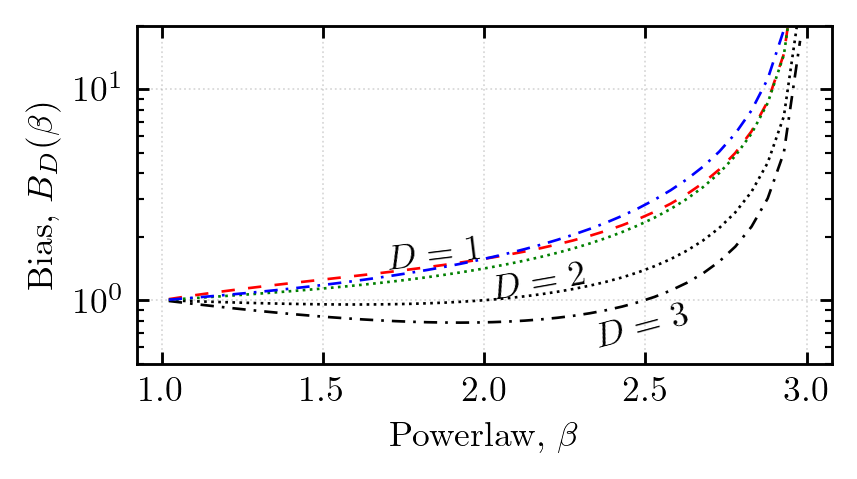

In [20]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

Ds = [1., 2., 3.]
Hs = np.linspace(0.01, 0.99, 40)

d_bias1 = []

for _d in Ds:
    vald = []
    for _hs in Hs:
        vald.append(np.float64(BIAS.subs({beta: 1. + 2.*_hs, D: _d, b: 1.}).evalf()))
    d_bias1.append(np.array(vald))

ax.plot(1. + 2.*Hs, d_bias1[0], linestyle=(0,(5,5)), color='red', linewidth=0.75, label='D=1')
ax.plot(1. + 2.*Hs, d_bias1[1], linestyle=':', color='black', linewidth=0.75, label='D=2')
ax.plot(1. + 2.*Hs, d_bias1[2], linestyle=(0,(5,3,1,3)), color='black', linewidth=0.75, label='D=3')


d_bias2 = []

for _d in [2., 3.]:
    vald = []
    __b = np.sqrt(2.*_d - 2.)
    for _hs in Hs:
        vald.append(np.float64(BIAS.subs({beta: 1. + 2.*_hs, D: _d, b: __b}).evalf()))
    d_bias2.append(np.array(vald))

ax.plot(1. + 2.*Hs, d_bias2[0], linestyle=':', color='green', linewidth=0.75, label='D=2')
ax.plot(1. + 2.*Hs, d_bias2[1], linestyle=(0,(5,3,1,3)), color='blue', linewidth=0.75, label='D=3')



ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_yscale('log')

ax.text(0.5, 0.385, r'$D=1$', transform=ax.transAxes, ha='right', va='top', rotation=7)
ax.text(0.65, 0.31, r'$D=2$', transform=ax.transAxes, ha='right', va='top', rotation=10)
ax.text(0.8, 0.19, r'$D=3$', transform=ax.transAxes, ha='right', va='top', rotation=15)

ax.set_xlabel(r'Powerlaw, $\beta$')
ax.set_ylabel(r'Bias, $B_D(\beta)$')

ax.set_ylim((5e-1, 20))

fig.savefig('plots/powerlaw_D_bias.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/powerlaw_D_bias.png', transparent=True, bbox_inches='tight', pad_inches=0)


In [ ]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

Ds = [1., 2., 3.]
Hs = np.linspace(0.01, 0.99, 40)

d_bias1 = []

for _d in Ds:
    vald = []
    for _hs in Hs:
        vald.append(np.float64(BIAS.subs({beta: 1. + 2.*_hs, D: _d, b: 1.}).evalf()))
    d_bias1.append(np.array(vald))

ax.plot(1. + 2.*Hs, d_bias1[0], linestyle=(0,(5,5)), color='red', linewidth=0.75, label='D=1')
#ax.plot(1. + 2.*Hs, d_bias[1], linestyle=':', color='black', linewidth=0.75, label='D=2')
#ax.plot(1. + 2.*Hs, d_bias[2], linestyle=(0,(5,3,1,3)), color='black', linewidth=0.75, label='D=3')


d_bias2 = []

for _d in [2., 3.]:
    vald = []
    __b = np.sqrt(2.*_d - 2.)
    for _hs in Hs:
        vald.append(np.float64(BIAS.subs({beta: 1. + 2.*_hs, D: _d, b: __b}).evalf()))
    d_bias2.append(np.array(vald))

ax.plot(1. + 2.*Hs, d_bias2[0], linestyle=':', color='green', linewidth=0.75, label='D=2')
ax.plot(1. + 2.*Hs, d_bias2[1], linestyle=(0,(5,3,1,3)), color='blue', linewidth=0.75, label='D=3')



ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_yscale('log')

# ax.text(0.5, 0.385, r'$D=1$', transform=ax.transAxes, ha='right', va='top', rotation=7)
# ax.text(0.65, 0.31, r'$D=2$', transform=ax.transAxes, ha='right', va='top', rotation=10)
# ax.text(0.8, 0.19, r'$D=3$', transform=ax.transAxes, ha='right', va='top', rotation=15)

ax.set_xlabel(r'Powerlaw, $\beta$')
ax.set_ylabel(r'Bias, $B_D(\beta)$')

ax.set_ylim((5e-1, 20))

fig.savefig('plots/powerlaw_D_bias.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/powerlaw_D_bias.png', transparent=True, bbox_inches='tight', pad_inches=0)


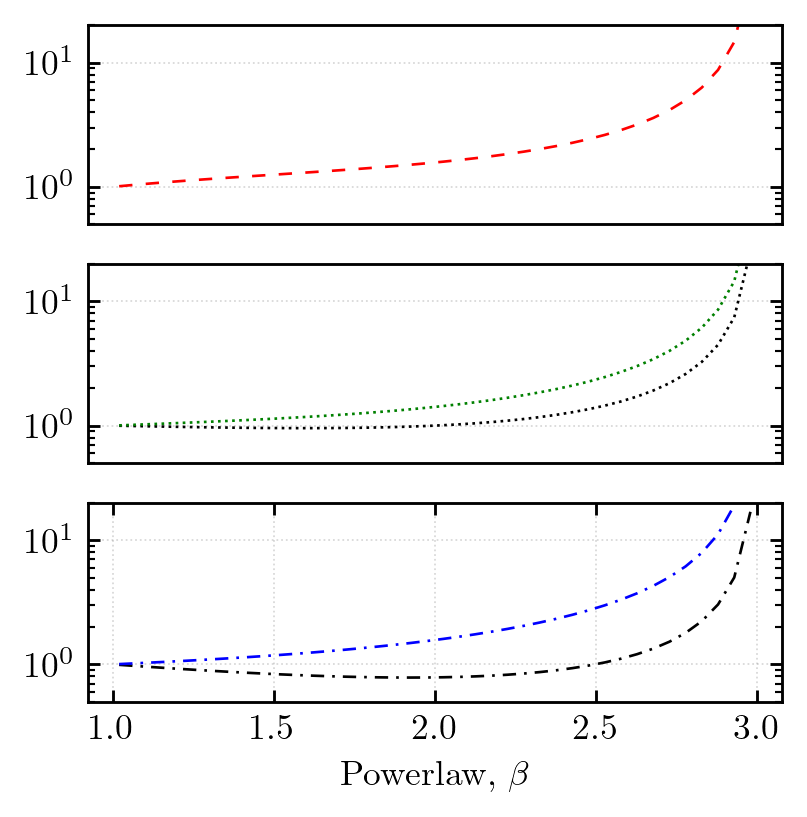

In [19]:

fig, axs = plt.subplots(3, 1, figsize=(3.5, 2.*1.75), dpi=256)

Ds = [1., 2., 3.]
Hs = np.linspace(0.01, 0.99, 40)

d_bias1 = []

for _d in Ds:
    vald = []
    for _hs in Hs:
        vald.append(np.float64(BIAS.subs({beta: 1. + 2.*_hs, D: _d, b: 1.}).evalf()))
    d_bias1.append(np.array(vald))

axs[0].plot(1. + 2.*Hs, d_bias1[0], linestyle=(0,(5,5)), color='red', linewidth=0.75, label='D=1')
axs[1].plot(1. + 2.*Hs, d_bias1[1], linestyle=':', color='black', linewidth=0.75, label='D=2')
axs[2].plot(1. + 2.*Hs, d_bias1[2], linestyle=(0,(5,3,1,3)), color='black', linewidth=0.75, label='D=3')


d_bias2 = []

for _d in [2., 3.]:
    vald = []
    __b = np.sqrt(2.*_d - 2.)
    for _hs in Hs:
        vald.append(np.float64(BIAS.subs({beta: 1. + 2.*_hs, D: _d, b: __b}).evalf()))
    d_bias2.append(np.array(vald))

axs[1].plot(1. + 2.*Hs, d_bias2[0], linestyle=':', color='green', linewidth=0.75, label='D=2')
axs[2].plot(1. + 2.*Hs, d_bias2[1], linestyle=(0,(5,3,1,3)), color='blue', linewidth=0.75, label='D=3')


for ax in axs:
    ax.yaxis.set_ticks_position('both')
    ax.xaxis.set_ticks_position('both')
    ax.tick_params(axis='y', direction='in')
    ax.tick_params(axis='y', direction='in', which='minor')
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='x', direction='in', which='minor')
    ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

    ax.set_yscale('log')

    ax.set_ylim((5e-1, 20))

axs[0].set_xticks([])
axs[1].set_xticks([])

# ax.text(0.5, 0.385, r'$D=1$', transform=ax.transAxes, ha='right', va='top', rotation=7)
# ax.text(0.65, 0.31, r'$D=2$', transform=ax.transAxes, ha='right', va='top', rotation=10)
# ax.text(0.8, 0.19, r'$D=3$', transform=ax.transAxes, ha='right', va='top', rotation=15)

axs[2].set_xlabel(r'Powerlaw, $\beta$')
#axs[].set_ylabel(r'Bias, $B_D(\beta)$')

fig.savefig('plots/powerlaw_D_bias.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/powerlaw_D_bias.png', transparent=True, bbox_inches='tight', pad_inches=0)


In [39]:


k, l = symbols('k, ell', positive=True, real=True)
B, b = symbols('B, b', real=True)
A = symbols('A', positive=True, real=True)
beta, H = symbols('beta, H', positive=True, real=True)
u = symbols('u', positive=True, real=True)

D = symbols('D', positive=True, integer=True)
D = S(3)

ftD = gamma(D/S(2)) * besselj(D/S(2) - S(1), k*l) / (k*l / S(2))**(D/S(2) - S(1))
ftD = ftD.simplify()
OD = S(2)*pi**(D/S(2))/gamma(D/S(2))
CD = integrate(ftD, (l, 0, oo))

## INSTEAD, WE SAY THAT THE ACF IS THE LONGITUDINAL ONE
fD = (exp(-A*l)).simplify()
gD = (Rational(1,2) * diff(l**2 * fD, l) / l).simplify()
acfD = (u**2 * diff(l**3 * fD, l) / l**2).simplify()
acfD2 = (u**2 * (fD + S(2)*gD)).simplify()

display(Eq(symbols(r'f(\ell)'), fD))
display(Eq(symbols(r'g(\ell)'), gD))
display(Eq(symbols(r'\bar{R}(\ell)'), acfD))
display(Eq(symbols(r'\bar{R}_{2}(\ell)'), acfD2))


display(limit(u**2 * fD, l, 0))
display(limit(u**2 * gD, l, 0))
display(limit(acfD, l, 0))


ED = (integrate(u**2 * fD * (sin(k*l)/(k*l) - cos(k*l))*(k*l)**2, (l, 0, oo)) * OD**2 / (2*pi)**3).simplify()
ED2 = (integrate(acfD * (sin(k*l)/(k*l)) * (k*l)**2, (l, 0, oo)) * OD**2 / (2*pi)**3).simplify()

display(Eq(symbols(r'\mathcal{E}(k)'), ED))
display(Eq(symbols(r'\mathcal{E}(k)'), ED2))

display(integrate(ED, (k, 0, oo)))


SFp = (S(2) * u**2 * (S(1) - fD)).simplify()
SF = (S(2) * (limit(acfD, l, 0) - acfD)).simplify()

display(Eq(symbols(r'S^{\parallel}(\ell)'), SFp))
display(Eq(symbols(r'\bar{S}(\ell)'), SF))


SF2 = (diff(l**3 * SFp, l) / l**2).simplify()
display(Eq(symbols(r'\bar{S}_{2}(\ell)'), SF2))


display(limit(SFp, l, oo))
display(limit(SF, l, oo))
display(limit(SF2, l, oo))


eq_ED = (Rational(1,2) * (B/b) * l**2 * diff(S(2) * (S(1) - acfD), l)).subs({l: b/k}).simplify()
eq_ED2 = (Rational(3,4) * (B/b) * l**2 * diff(S(2) * (u**2 - u**2*fD), l)).subs({l: b/k}).simplify()

display(Eq(symbols(r'\widetilde{\mathcal{E}}^{\parallel}(k)'), eq_ED))
display(Eq(symbols(r'\widetilde{\mathcal{E}}^{S}(k)'), eq_ED2))



Eq(f(\ell), exp(-A*ell))

Eq(g(\ell), (-A*ell + 2)*exp(-A*ell)/2)

Eq(\bar{R}(\ell), u**2*(-A*ell + 3)*exp(-A*ell))

Eq(\bar{R}_{2}(\ell), u**2*(-A*ell + 3)*exp(-A*ell))

u**2

...

2*u**2

6*u**2

6*u**2

Eq(\widetilde{\mathcal{E}}^{\parallel}(k), A*B*b*u**2*(-A*b + 4*k)*exp(-A*b/k)/k**3)

Eq(\widetilde{\mathcal{E}}^{S}(k), 3*A*B*b*u**2*exp(-A*b/k)/(2*k**2))

In [42]:

L1 = integrate(u**2 * fD, (l, 0, oo)).simplify()
L2 = integrate(acfD, (l, 0, oo)).simplify()
L3 = (integrate(ED * CD, (k, 0, oo))).simplify()

display(L1)
display(L2)
display(L3)


u**2/A

2*u**2/A

2*u**2/A

In [8]:

beta_t = (k * diff(ln(ED), k)).simplify()
beta_e = (k * diff(ln(eq_EDk), k)).simplify()

display(beta_t)
#display(limit(beta_t, k, oo))
display(beta_e)
#display(limit(beta_e, k, oo))

for p in solve(Eq(beta_t, 0), k):
    display(p)
for p in solve(Eq(beta_e, 0), k):
    display(p)


2*(2*A**2 - k**2)/(A**2 + k**2)

(A**2*b**2 - 7*A*b*k + 8*k**2)/(k*(A*b - 4*k))

sqrt(2)*A

A*b*(7 - sqrt(17))/16

A*b*(sqrt(17) + 7)/16

In [9]:
display((sqrt(2) * 16 / (7 - sqrt(17))).evalf())
display((sqrt(2) * 16 / (7 + sqrt(17))).evalf())

7.86522341572848

2.03427152088318

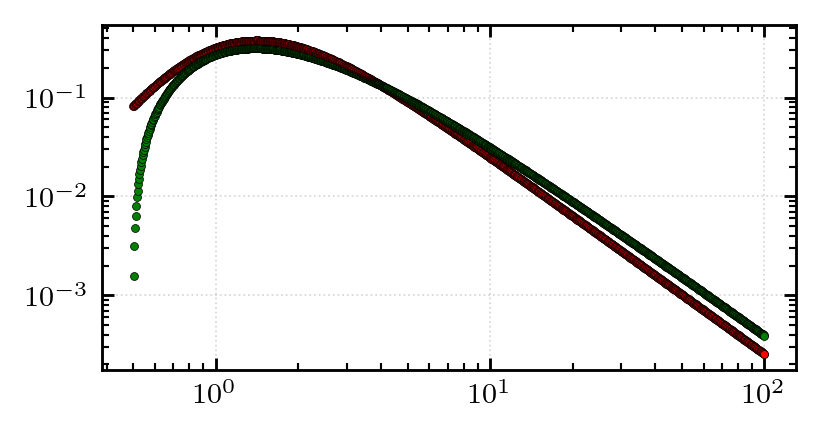

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

_k = np.exp(np.linspace(np.log(5e-1), np.log(1e2), 1000))

for __k in _k:
    spec1 = ED.subs({u: S(1), A: S(1), k: __k}).evalf()
    ax.scatter(__k, spec1, marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black')
    spec2 = eq_EDk.subs({B: S(1), b: S(2), A: S(1), u: S(1), k: __k}).evalf()
    ax.scatter(__k, spec2, marker='o', s=5., color='green', zorder=2, linewidth=0.2, edgecolor='black')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_yscale('log')
ax.set_xscale('log')


In [11]:

# k, l = symbols('k, ell', positive=True, real=True)
# B, b = symbols('B, b', real=True)
# A = symbols('A', positive=True, real=True)
# beta, H = symbols('beta, H', positive=True, real=True)

# D = symbols('D', positive=True, integer=True)

# ftD = gamma(D/S(2)) * besselj(D/S(2) - S(1), k*l) / (k*l / S(2))**(D/S(2) - S(1))
# ftD = ftD.subs({D: S(1)}).simplify()
# display(ftD)

# ED = (S(2)/pi) * (A**S(2) / (A**S(2) + k**S(2)))**(beta/S(2))

# display(ED.simplify())

# eq_ED = (B/b) * S(1)/S(2) * l**2 * diff(S(2) * integrate((S(1) - ftD) * ED, (k, 0, oo)), l)
# eq_ED = eq_ED.simplify().args[0][0].subs({l: b/k}).simplify()
# display(eq_ED)
# eq_ED = eq_ED.subs({beta: S(1) + S(2)*H, B: S(1)}).simplify()
# display(eq_ED)

# beta_e = (k * diff(ln(eq_ED), k)).simplify()
# display(beta_e)

# #display(limit(beta_e, k, oo).simplify())
# #display(limit(beta_e, k, 0).simplify())


In [12]:
# beta_e = (k * diff(ln(eq_ED), k)).simplify()#.expand(func=True).simplify()
# display(beta_e)

In [13]:

# t = beta_e.subs({b: sqrt(S(2)*D - S(2)), k: A, H: Rational(1,2)}).simplify()
# display(t)
# display(t.subs({D: S(1)}).simplify())
# display(t.subs({D: S(2)}).simplify())
# display(t.subs({D: S(3)}).simplify())


In [14]:

# ke0 = Eq(beta_e.subs({H: Rational(1,2), b: sqrt(S(2)*D - S(2))}), 0)
# display(ke0)
# points = solve(ke0, k)
# for p in points:
#     display(p.simplify())
